In [1]:
import datetime as dt

import polars as pl
import sf_quant.data as sfd
import matplotlib.pyplot as plt
import seaborn as sns

/home/msch2022/SATV/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-08 14:09:19,608	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# Parameters
start = dt.date(2000, 1, 1)
end = dt.date(2024, 12, 31)
signal_name = "mom*satv_monthly"
gamma = 75

# Load MVO weights (monthly)
weights = pl.read_parquet(f"weights/{signal_name}/{gamma}/*.parquet")


In [3]:
# Load returns + spread + price
returns = (
    sfd.load_assets(
        start=start,
        end=end,
        columns=["date", "barrid", "return", "bid_ask_spread", "price"],
        in_universe=True
    )
    .sort("date", "barrid")
    .select(
        "date",
        "barrid",

        # forward return (convert % → decimal)
        pl.col("return")
        .truediv(100)
        .shift(-1)
        .over("barrid")
        .alias("forward_return"),

        # spread as % of price (decimal)
        (-pl.col("bid_ask_spread") / pl.col("price")).alias("spread_pct"),
    )
)

# --- MONTHLY WEIGHTS → DAILY EXPANSION ---

# Step 1: collapse to month-end weights
weights = (
    weights
    .with_columns(pl.col("date").dt.truncate("1mo").alias("month"))
    .sort("barrid", "date")
    .group_by(["barrid", "month"])
    .agg(pl.col("weight").last().alias("weight"))
)

# Step 2: build daily calendar
calendar = returns.select("date").unique().sort("date")

# Step 3: expand weights across each day of the month
weights_daily = (
    calendar
    .with_columns(pl.col("date").dt.truncate("1mo").alias("month"))
    .join(weights, on="month", how="left")
)

# --- BACKTEST (NO COSTS) ---

portfolio_returns = (
    weights_daily.join(returns, on=["date", "barrid"], how="left")
    .group_by("date")
    .agg(pl.col("forward_return").mul(pl.col("weight")).sum().alias("return"))
    .sort("date")
)


# Cumulative log returns
cumulative_returns = portfolio_returns.select(
    "date",
    pl.col("return").log1p().cum_sum().mul(100).alias("cumulative_return")
)

shape: (1, 3)
┌─────────────┬────────────┬──────────┐
│ mean_return ┆ volatility ┆ sharpe   │
│ ---         ┆ ---        ┆ ---      │
│ f64         ┆ f64        ┆ f64      │
╞═════════════╪════════════╪══════════╡
│ 18.770276   ┆ 12.433466  ┆ 1.509658 │
└─────────────┴────────────┴──────────┘


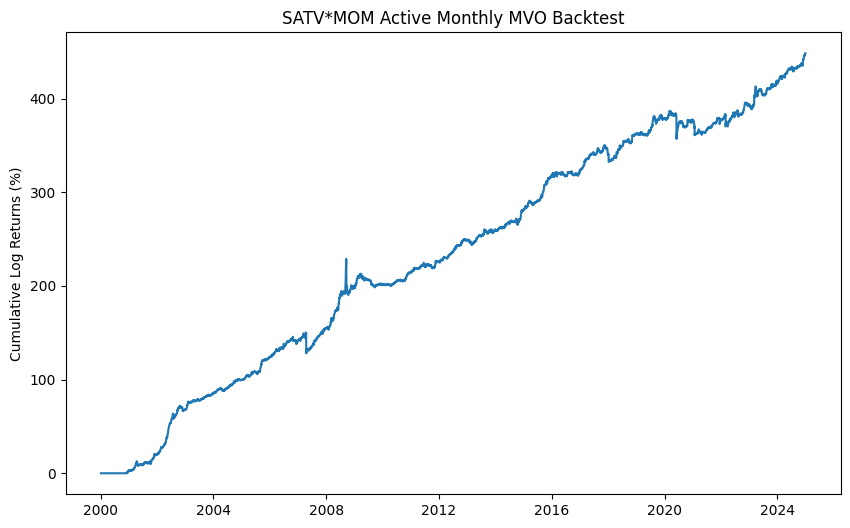

In [4]:
# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(cumulative_returns, x="date", y="cumulative_return")
plt.title("SATV*MOM Active Monthly MVO Backtest")
plt.xlabel("")
plt.ylabel("Cumulative Log Returns (%)")
plt.savefig("backtest_chart.png")

# Summary stats
summary = portfolio_returns.select(
    pl.col("return").mean().mul(252 * 100).alias("mean_return"),
    pl.col("return").std().mul(pl.lit(252).sqrt() * 100).alias("volatility"),
).with_columns(
    pl.col("mean_return").truediv(pl.col("volatility")).alias("sharpe")
)

print(summary)

In [6]:
import statsmodels.api as sm

In [13]:
merged[["return", "MOM"]].corr()

,return,MOM
return,1.000000,0.055447
MOM,0.055447,1.000000


In [14]:
portfolio_returns_cost = (
    weights_daily.join(returns, on=["date", "barrid"], how="left")
    .with_columns(
        (pl.col("forward_return") + pl.col("spread_pct") * pl.col("weight").abs())
        .alias("net_return")
    )
    .group_by("date")
    .agg(pl.col("net_return").sum().alias("return"))
)

In [15]:
# =========================
# FF6 REGRESSION (NO pandas_datareader)
# =========================

import pandas as pd
import numpy as np
import zipfile
import io
import requests

# -------------------------
# 1. Convert portfolio returns to pandas
# -------------------------
df = portfolio_returns.to_pandas()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

# -------------------------
# 2. Download FF5 factors
# -------------------------
ff5_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"

response = requests.get(ff5_url)
z = zipfile.ZipFile(io.BytesIO(response.content))
ff5_file = z.open(z.namelist()[0])

ff5 = pd.read_csv(ff5_file, skiprows=3)
ff5 = ff5.rename(columns={ff5.columns[0]: "date"})

# Clean end rows
ff5 = ff5[ff5["date"].str.isnumeric()]
ff5["date"] = pd.to_datetime(ff5["date"], format="%Y%m%d")
ff5 = ff5.set_index("date")

# Convert to decimal
ff5 = ff5.astype(float) / 100.0

# Rename
ff5 = ff5.rename(columns={
    "Mkt-RF": "MKT_RF",
    "SMB": "SMB",
    "HML": "HML",
    "RMW": "RMW",
    "CMA": "CMA",
    "RF": "RF"
})

# -------------------------
# 3. Download Momentum
# -------------------------
mom_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip"

response = requests.get(mom_url)
z = zipfile.ZipFile(io.BytesIO(response.content))
mom_file = z.open(z.namelist()[0])

mom = pd.read_csv(mom_file, skiprows=13)
mom = mom.rename(columns={mom.columns[0]: "date"})

mom = mom[mom["date"].str.isnumeric()]
mom["date"] = pd.to_datetime(mom["date"], format="%Y%m%d")
mom = mom.set_index("date")

mom = mom.astype(float) / 100.0
mom = mom.rename(columns={"Mom": "MOM"})

# -------------------------
# 4. Merge factors
# -------------------------
factors = ff5.join(mom, how="inner")

# -------------------------
# 5. Merge with strategy returns
# -------------------------
merged = df.join(factors, how="inner")

merged["excess_return"] = merged["return"] - merged["RF"]
merged = merged.dropna()

# -------------------------
# 6. Regression
# -------------------------
y = merged["excess_return"].values

X = merged[["MKT_RF", "SMB", "HML", "RMW", "CMA", "MOM"]].values
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

In [16]:
print(model.summary())

alpha_daily = model.params[0]
alpha_annual = alpha_daily * 252

print("\n=========================")
print(f"Daily Alpha: {alpha_daily:.6f}")
print(f"Annual Alpha: {alpha_annual:.4%}")
print("=========================")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.553
Date:                Wed, 08 Apr 2026   Prob (F-statistic):            0.00163
Time:                        14:17:49   Log-Likelihood:                 21587.
No. Observations:                6289   AIC:                        -4.316e+04
Df Residuals:                    6282   BIC:                        -4.311e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007   9.89e-05      6.855      0.0

In [17]:
# =========================
# CLEAN FACTOR TABLE OUTPUT
# =========================

import pandas as pd

# Extract results
params = model.params
tstats = model.tvalues

# Map variable names
var_names = ["Intercept", "mkt_rf", "smb", "hml", "rmw", "cma", "mom"]

# Build table
table = pd.DataFrame({
    "variable": var_names,
    "coefficient": params,
    "tstat": tstats
})

# Pretty print
print("\n" + "="*50)
print(f"{'variable':<12} | {'coefficient':>12} | {'tstat':>10}")
print("-"*50)

for _, row in table.iterrows():
    print(f"{row['variable']:<12} | {row['coefficient']:>12.6f} | {row['tstat']:>10.5f}")

print("="*50)

# Optional: alpha summary
alpha_daily = params[0]
alpha_annual = alpha_daily * 252

print(f"\nAlpha (annual): {alpha_annual:.2%}")


variable     |  coefficient |      tstat
--------------------------------------------------
Intercept    |     0.000678 |    6.85498
mkt_rf       |    -0.009891 |   -1.09746
smb          |    -0.004157 |   -0.25317
hml          |    -0.005653 |   -0.34240
rmw          |    -0.009492 |   -0.45544
cma          |    -0.013270 |   -0.47592
mom          |     0.037074 |    3.53997

Alpha (annual): 17.08%


In [19]:
# =========================
# QUADRANT ANALYSIS (SATV × MOM)
# =========================

import polars as pl

# --- STEP 1: Recreate signals (aligned with your returns) ---

signals = (
    sfd.load_assets(
        start=start,
        end=end,
        columns=[
            "date", "barrid", "price", "return",
            "market_cap", "daily_volume"
        ],
        in_universe=True
    )
    .with_columns(pl.col("return").truediv(100))
    .sort("date", "barrid")
    .with_columns(
        (pl.col("market_cap") / pl.col("price")).alias("shrout"),
        (pl.col("daily_volume") / (pl.col("market_cap") / pl.col("price"))).alias("turnover"),
    )
    .with_columns(
        pl.col("turnover")
        .rolling_mean(230)
        .shift(21)
        .over("barrid")
        .alias("turnover_mean"),

        pl.col("turnover")
        .rolling_std(230)
        .shift(21)
        .over("barrid")
        .alias("turnover_std"),
    )
    .with_columns(
        ((pl.col("turnover") - pl.col("turnover_mean")) / pl.col("turnover_std"))
        .alias("satv_raw"),

        pl.col("return")
        .log1p()
        .rolling_sum(230)
        .shift(21)
        .over("barrid")
        .alias("mom_raw"),
    )
    .filter(
        pl.col("satv_raw").is_not_null(),
        pl.col("mom_raw").is_not_null(),
    )
    .with_columns(
        # cross-sectional z-score
        ((pl.col("satv_raw") - pl.col("satv_raw").mean().over("date")) /
         pl.col("satv_raw").std().over("date")).alias("satv_z_cs"),

        ((pl.col("mom_raw") - pl.col("mom_raw").mean().over("date")) /
         pl.col("mom_raw").std().over("date")).alias("mom_z_cs"),
    )
    .select("date", "barrid", "satv_z_cs", "mom_z_cs")
)

# --- STEP 2: Assign quadrants ---

signals = signals.with_columns(
    pl.when((pl.col("satv_z_cs") > 0) & (pl.col("mom_z_cs") > 0)).then(pl.lit("Q1: High SATV, High MOM"))
    .when((pl.col("satv_z_cs") < 0) & (pl.col("mom_z_cs") > 0)).then(pl.lit("Q2: Low SATV, High MOM"))
    .when((pl.col("satv_z_cs") < 0) & (pl.col("mom_z_cs") < 0)).then(pl.lit("Q3: Low SATV, Low MOM"))
    .when((pl.col("satv_z_cs") > 0) & (pl.col("mom_z_cs") < 0)).then(pl.lit("Q4: High SATV, Low MOM"))
    .otherwise(None)
    .alias("quadrant")
)

# --- STEP 3: Join with forward returns ---

returns_fwd = (
    sfd.load_assets(
        start=start,
        end=end,
        columns=["date", "barrid", "return"],
        in_universe=True
    )
    .sort("date", "barrid")
    .with_columns(
        pl.col("return").truediv(100)
        .shift(-1)
        .over("barrid")
        .alias("fwd_return")
    )
    .select("date", "barrid", "fwd_return")
)

df = signals.join(returns_fwd, on=["date", "barrid"], how="inner")

# --- STEP 4: Equal-weight returns by quadrant ---

quad_returns = (
    df
    .group_by(["date", "quadrant"])
    .agg(pl.col("fwd_return").mean().alias("ret"))
    .sort("date")
)

# --- STEP 5: Aggregate performance ---

summary = (
    quad_returns
    .group_by("quadrant")
    .agg(
        pl.col("ret").mean().mul(252).alias("mean_return"),
        pl.col("ret").std().mul((252)**0.5).alias("vol"),
    )
    .with_columns(
        (pl.col("mean_return") / pl.col("vol")).alias("sharpe")
    )
    .sort("mean_return", descending=True)
)

print("\n=== QUADRANT PERFORMANCE ===")
print(summary)


=== QUADRANT PERFORMANCE ===
shape: (4, 4)
┌─────────────────────────┬─────────────┬──────────┬──────────┐
│ quadrant                ┆ mean_return ┆ vol      ┆ sharpe   │
│ ---                     ┆ ---         ┆ ---      ┆ ---      │
│ str                     ┆ f64         ┆ f64      ┆ f64      │
╞═════════════════════════╪═════════════╪══════════╪══════════╡
│ Q4: High SATV, Low MOM  ┆ 0.247874    ┆ 0.306236 ┆ 0.809419 │
│ Q1: High SATV, High MOM ┆ 0.196956    ┆ 0.22171  ┆ 0.888348 │
│ Q2: Low SATV, High MOM  ┆ 0.098171    ┆ 0.223293 ┆ 0.439651 │
│ Q3: Low SATV, Low MOM   ┆ 0.071429    ┆ 0.292331 ┆ 0.244345 │
└─────────────────────────┴─────────────┴──────────┴──────────┘


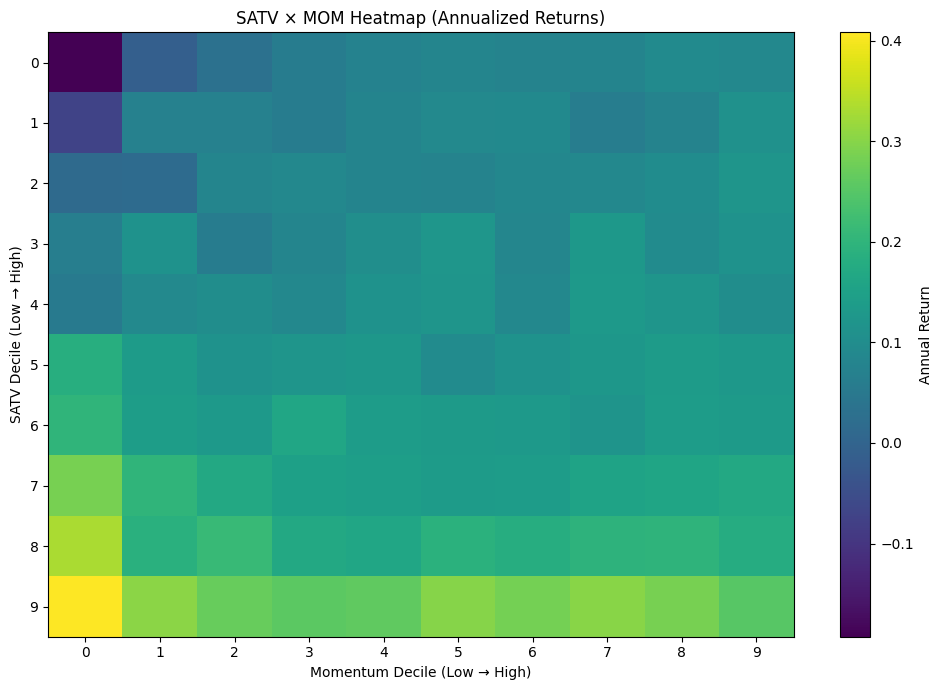

In [20]:
# =========================
# SATV × MOM HEATMAP (DECILES)
# =========================

import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: Build signals (same as before) ---

signals = (
    sfd.load_assets(
        start=start,
        end=end,
        columns=[
            "date", "barrid", "price", "return",
            "market_cap", "daily_volume"
        ],
        in_universe=True
    )
    .with_columns(pl.col("return").truediv(100))
    .sort("date", "barrid")
    .with_columns(
        (pl.col("market_cap") / pl.col("price")).alias("shrout"),
        (pl.col("daily_volume") / (pl.col("market_cap") / pl.col("price"))).alias("turnover"),
    )
    .with_columns(
        pl.col("turnover")
        .rolling_mean(230)
        .shift(21)
        .over("barrid")
        .alias("turnover_mean"),

        pl.col("turnover")
        .rolling_std(230)
        .shift(21)
        .over("barrid")
        .alias("turnover_std"),
    )
    .with_columns(
        ((pl.col("turnover") - pl.col("turnover_mean")) / pl.col("turnover_std"))
        .alias("satv_raw"),

        pl.col("return")
        .log1p()
        .rolling_sum(230)
        .shift(21)
        .over("barrid")
        .alias("mom_raw"),
    )
    .filter(
        pl.col("satv_raw").is_not_null(),
        pl.col("mom_raw").is_not_null(),
    )
)

# --- STEP 2: Cross-sectional deciles ---

signals = signals.with_columns(
    pl.col("satv_raw").rank("dense").over("date") /
    pl.col("satv_raw").count().over("date")
).with_columns(
    (pl.col("satv_raw") * 0 + pl.col("satv_raw").rank("dense").over("date") /
     pl.col("satv_raw").count().over("date")).alias("satv_pct"),

    (pl.col("mom_raw").rank("dense").over("date") /
     pl.col("mom_raw").count().over("date")).alias("mom_pct"),
)

signals = signals.with_columns(
    (pl.col("satv_pct") * 10).floor().clip(0, 9).cast(pl.Int64).alias("satv_decile"),
    (pl.col("mom_pct") * 10).floor().clip(0, 9).cast(pl.Int64).alias("mom_decile"),
)

# --- STEP 3: Forward returns ---

returns_fwd = (
    sfd.load_assets(
        start=start,
        end=end,
        columns=["date", "barrid", "return"],
        in_universe=True
    )
    .sort("date", "barrid")
    .with_columns(
        pl.col("return").truediv(100)
        .shift(-1)
        .over("barrid")
        .alias("fwd_return")
    )
    .select("date", "barrid", "fwd_return")
)

df = signals.join(returns_fwd, on=["date", "barrid"], how="inner")

# --- STEP 4: Average returns per cell ---

heatmap_df = (
    df
    .group_by(["satv_decile", "mom_decile"])
    .agg(pl.col("fwd_return").mean().alias("ret"))
    .sort(["satv_decile", "mom_decile"])
    .to_pandas()
)

# Pivot to matrix
heatmap_matrix = heatmap_df.pivot(
    index="satv_decile",
    columns="mom_decile",
    values="ret"
)

# Annualize
heatmap_matrix = heatmap_matrix * 252

# --- STEP 5: Plot ---

plt.figure(figsize=(10, 7))
plt.imshow(heatmap_matrix, aspect="auto")

plt.colorbar(label="Annual Return")
plt.xlabel("Momentum Decile (Low → High)")
plt.ylabel("SATV Decile (Low → High)")
plt.title("SATV × MOM Heatmap (Annualized Returns)")

plt.xticks(range(10))
plt.yticks(range(10))

plt.tight_layout()
plt.show()